# CNN for Image Classification

**Unit:** Unit 4: Neural Networks Fundamentals

In `02_cnn_rnn_architectures.ipynb` we only *looked at* a CNN's structure — we never trained one. Here is the problem that makes CNNs worth training: a dense network flattens a 28x28 image into 784 independent numbers, so it throws away the one thing that makes an image an image — nearby pixels form strokes, edges, and corners *together*. A convolutional layer instead slides a small filter across the image, so the same edge detector works in every location, using far fewer weights. In this notebook we test that claim experimentally: same data, same training budget, dense baseline vs. CNN — then we go one step further and borrow a network someone else already trained on 1.3 million photos.

## 📚 Learning Objectives

By completing this notebook, you will:
- Train a dense MLP baseline and a small Conv-Pool-Conv-Pool-Dense CNN on the same MNIST subset
- Compare their test accuracy and parameter counts from actual printed results
- Inspect a grid of predictions, including the images the CNN gets wrong
- Use a frozen pre-trained MobileNetV2 as a feature extractor (transfer learning)

## 🔗 Where this fits

**Builds on:** Unit 4, lesson 02 "Deep Learning Architectures: CNNs and RNNs" — the CNN described there is trained here against a dense baseline, by the recipe of Unit 3, lesson 04: define a loss, then use gradient descent to nudge the parameters.

**Used later in:** Course 08 (AIAT 122) — Unit 2, which goes from this small CNN to ResNet-class transfer learning.

---


## 🎯 A dermatologist-level classifier — and the ink that fooled one

In **2017** *Nature* published Esteva et al., *Dermatologist-level classification
of skin cancer with deep neural networks*. The method is the one in the second
half of this notebook: take an Inception-v3 network already trained on ImageNet's
everyday photographs, and fine-tune it on **129,450 clinical images** covering
2,032 diseases. Tested against **21 board-certified dermatologists**, it matched
their performance on the two classification tasks the paper reports.

Now the counterweight, which matters more. Skin lesions that a clinician suspects
are often photographed with the doctor's **ink marking** beside them. In 2019
Winkler and colleagues showed in *JAMA Dermatology* that adding such a marking to
an image raised a CNN's melanoma probability — the network had partly learned
*"a doctor was worried about this one"* rather than *"this lesion looks
malignant"*. Same recipe, same accuracy on the test set, and a feature that
disappears the moment the model meets images taken by patients at home.

Hold both results at once. Transfer learning genuinely delivers clinician-level
numbers from a few tens of thousands of images. And a CNN will happily key on
whatever correlates with the label in the data you gave it, including things you
did not know were in the picture. That is the same failure mode you met in Unit 3
notebook 05 with the husky-and-snow classifier — and the same reason that notebook
existed.

### What goes wrong without convolutions

A dense layer flattens a 28×28 image into 784 unrelated numbers. Shuffle every
image's pixels the same way and the dense model learns exactly as well — proof
that it never used the fact that neighbouring pixels form strokes. It must
therefore learn a separate detector for every position where a stroke could
appear, from data. A convolution builds the answer into the wiring: one 3×3
filter, reused everywhere. The next two cells measure what that is worth under an
identical training budget.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- MNIST handwritten digits via `keras.datasets.mnist` (already cached locally) — we use a **subset of 6,000 training / 1,000 test images** to keep training classroom-fast
- Pre-trained MobileNetV2 ImageNet weights (already cached locally) for the transfer-learning demo

**Outputs:** What you'll see when you run the cells

- Printed test accuracy for the dense MLP baseline vs. the CNN, plus parameter counts
- A figure of sample predictions including misclassified digits
- A transfer-learning demo: accuracy of a tiny classifier trained on frozen MobileNetV2 features, and 3 classified sample images

---

In [1]:
# Setup: a 6k/1k subset of MNIST, scaled to [0,1] — small enough to train both a
# dense network and a CNN on CPU in seconds, so we can compare them fairly.
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

keras.utils.set_random_seed(42)  # reproducible runs

# Load MNIST (cached in ~/.keras) and take a small subset for fast CPU training
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()
x_train, y_train = x_train_full[:6000], y_train_full[:6000]
x_test, y_test = x_test_full[:1000], y_test_full[:1000]

# Scale pixels from [0, 255] to [0, 1]
x_train_n = x_train.astype("float32") / 255.0
x_test_n = x_test.astype("float32") / 255.0

print("Full MNIST:   ", x_train_full.shape[0], "train /", x_test_full.shape[0], "test images")
print("Our subset:   ", x_train.shape[0], "train /", x_test.shape[0], "test images")
print("Image shape:  ", x_train.shape[1:], "grayscale, labels are digits 0-9")

Full MNIST:    60000 train / 10000 test images
Our subset:    6000 train / 1000 test images
Image shape:   (28, 28) grayscale, labels are digits 0-9


## Baseline: a dense MLP

**What:** the same kind of network we used in earlier notebooks — `Flatten` the image into 784 numbers, then two `Dense` layers.

**Why start here:** to judge whether convolutions help, we need a fair baseline trained on the *same* 6,000 images for the *same* 2 epochs. The MLP has no idea which pixels are neighbors: shuffling all 784 pixel positions the same way in every image would not change what it can learn.

In [2]:
# Baseline: a dense MLP must flatten the image, throwing away the 2D layout —
# every pixel gets its own independent weights.
mlp = keras.Sequential(
    [
        keras.Input(shape=(28, 28)),
        keras.layers.Flatten(),                       # 28x28 image -> 784 flat numbers
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),  # one probability per digit
    ],
    name="dense_mlp",
)
mlp.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

mlp.fit(x_train_n, y_train, epochs=2, batch_size=64, verbose=0)
mlp_loss, mlp_acc = mlp.evaluate(x_test_n, y_test, verbose=0)

print(f"MLP parameters:     {mlp.count_params():,}")
print(f"MLP test accuracy:  {mlp_acc:.3f}  (on {len(y_test)} test images, after 2 epochs)")

MLP parameters:     50,890
MLP test accuracy:  0.876  (on 1000 test images, after 2 epochs)


## Change one thing: convolution + pooling

We keep the data, the epochs, the batch size, and the optimizer identical, and change **only the architecture**: before the dense layers we insert two Conv-Pool blocks.

- **`Conv2D`** slides a small 3x3 filter over the image. The *same* 9 weights scan every location, so a stroke detector learned in one corner works everywhere (*weight sharing*).
- **`MaxPooling2D`** keeps the strongest response in each 2x2 patch, halving the resolution — the network becomes tolerant to a digit shifting by a pixel or two.

Stacking two blocks lets the second convolution combine edges into larger shapes (loops, crossings) before the dense head makes the final call.

In [3]:
# The CNN alternative: small filters slide over the image, so the same weights detect
# a pattern anywhere — fewer parameters AND awareness of spatial structure.
cnn = keras.Sequential(
    [
        keras.Input(shape=(28, 28, 1)),               # conv layers need a channel dimension
        keras.layers.Conv2D(16, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ],
    name="small_cnn",
)
cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

cnn.fit(x_train_n[..., None], y_train, epochs=2, batch_size=64, verbose=0)
cnn_loss, cnn_acc = cnn.evaluate(x_test_n[..., None], y_test, verbose=0)

print(f"CNN parameters:     {cnn.count_params():,}")
print(f"CNN test accuracy:  {cnn_acc:.3f}  (same {len(y_test)} test images, same 2 epochs)")
print()
print("=== Comparison on this run (same 6,000 train / 1,000 test subset) ===")
print(f"  Dense MLP : {mlp_acc:.3f} accuracy with {mlp.count_params():,} parameters")
print(f"  Small CNN : {cnn_acc:.3f} accuracy with {cnn.count_params():,} parameters")
print(f"  Difference: {cnn_acc - mlp_acc:+.3f} accuracy "
      f"({'CNN wins' if cnn_acc > mlp_acc else 'MLP wins' if mlp_acc > cnn_acc else 'tie'})")

CNN parameters:     30,762
CNN test accuracy:  0.925  (same 1000 test images, same 2 epochs)

=== Comparison on this run (same 6,000 train / 1,000 test subset) ===
  Dense MLP : 0.876 accuracy with 50,890 parameters
  Small CNN : 0.925 accuracy with 30,762 parameters
  Difference: +0.049 accuracy (CNN wins)


### What the numbers say

On this run the CNN reached **0.925** test accuracy vs. **0.876** for the dense MLP — a **+0.049** improvement — while using **fewer** parameters (30,762 vs. 50,890). Everything else was identical: same 6,000 training images, same 1,000 test images, 2 epochs, batch size 64, Adam. The only change was the architecture, so the gap is attributable to what convolutions add: weight sharing (one 3x3 filter reused across the whole image) and pooling's tolerance to small shifts. Both models would keep improving with more data and epochs; the point here is the gap under an identical small budget.

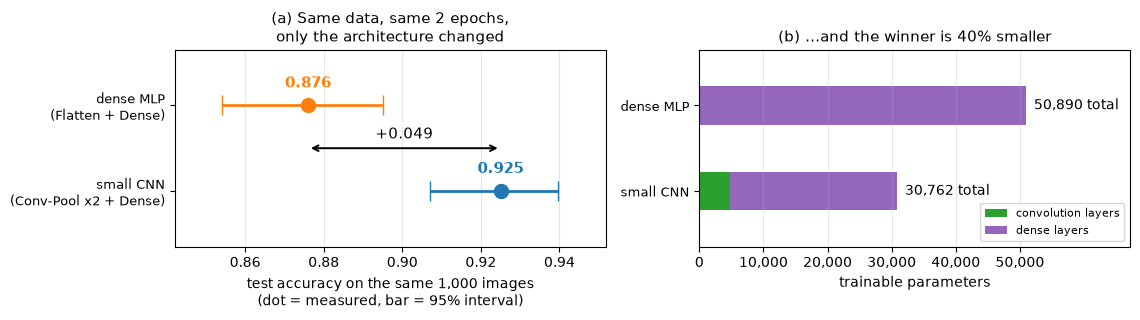

MLP  0.876  95% interval [0.854, 0.895]  50,890 parameters (0 conv / 50,890 dense)
CNN  0.925  95% interval [0.907, 0.940]  30,762 parameters (4,800 conv / 25,962 dense)
Do the two intervals overlap? NO - the gap is larger than the test-set noise


In [4]:
# WHAT/WHY: the +0.049 above is printed as text, and printed text is easy to read
# past. This cell draws the SAME two measured results - nothing is retrained - and adds
# the one thing the printed numbers cannot show: how much of that gap could be luck on
# a 1,000-image test set, and where each model spends its parameters.
import math

def wilson(acc, n, z=1.96):
    """95% confidence interval for an accuracy measured on n independent test items."""
    p, d = acc, 1 + z * z / n
    centre = (p + z * z / (2 * n)) / d
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return centre - half, centre + half

n_test = len(y_test)
models = [("dense MLP\n(Flatten + Dense)", mlp, mlp_acc, "tab:orange"),
          ("small CNN\n(Conv-Pool x2 + Dense)", cnn, cnn_acc, "tab:blue")]
cis = [wilson(a, n_test) for _, _, a, _ in models]

def conv_dense_split(model):
    """How many trainable parameters sit in convolutions vs in dense layers."""
    conv = sum(l.count_params() for l in model.layers
               if isinstance(l, keras.layers.Conv2D))
    return conv, model.count_params() - conv

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.5, 3.3))
ypos = [1, 0]  # MLP on the top row, CNN underneath

# --- (a) the accuracies, each with the uncertainty of a 1,000-image test set --------
for y, (label, _, acc, colour), (lo, hi) in zip(ypos, models, cis):
    axA.errorbar(acc, y, xerr=[[acc - lo], [hi - acc]], fmt="o", ms=10, capsize=7,
                 lw=2, color=colour, zorder=3)
    axA.annotate(f"{acc:.3f}", (acc, y), textcoords="offset points", xytext=(0, 13),
                 ha="center", fontsize=11, color=colour, fontweight="bold")
axA.annotate("", xy=(cnn_acc, 0.5), xytext=(mlp_acc, 0.5),
             arrowprops=dict(arrowstyle="<->", color="black", lw=1.4))
axA.annotate(f"+{cnn_acc - mlp_acc:.3f}", ((mlp_acc + cnn_acc) / 2, 0.5),
             textcoords="offset points", xytext=(0, 7), ha="center", fontsize=11)
axA.set_yticks(ypos)
axA.set_yticklabels([m[0] for m in models], fontsize=9)
axA.set_ylim(-0.65, 1.65)
lo_all = min(c[0] for c in cis) - 0.012
hi_all = max(c[1] for c in cis) + 0.012
axA.set_xlim(lo_all, hi_all)
axA.set_xlabel(f"test accuracy on the same {n_test:,} images\n"
               "(dot = measured, bar = 95% interval)")
axA.set_title("(a) Same data, same 2 epochs,\nonly the architecture changed", fontsize=11)
axA.grid(axis="x", alpha=0.3)

# --- (b) where the parameters actually live -----------------------------------------
splits = [conv_dense_split(m) for _, m, _, _ in models]
axB.barh(ypos, [s[0] for s in splits], height=0.45, color="tab:green",
         label="convolution layers")
axB.barh(ypos, [s[1] for s in splits], left=[s[0] for s in splits], height=0.45,
         color="tab:purple", label="dense layers")
for y, (conv, dense) in zip(ypos, splits):
    axB.annotate(f"{conv + dense:,} total", (conv + dense, y), fontsize=10,
                 va="center", ha="left", xytext=(6, 0), textcoords="offset points")
axB.set_yticks(ypos)
axB.set_yticklabels(["dense MLP", "small CNN"], fontsize=9)
axB.set_ylim(-0.65, 1.65)
axB.set_xlim(0, mlp.count_params() * 1.32)
axB.set_xlabel("trainable parameters")
axB.set_xticks([0, 10_000, 20_000, 30_000, 40_000, 50_000])
axB.set_xticklabels([f"{v:,}" for v in (0, 10_000, 20_000, 30_000, 40_000, 50_000)])
axB.set_title(f"(b) ...and the winner is "
              f"{(1 - cnn.count_params() / mlp.count_params()):.0%} smaller", fontsize=11)
axB.legend(fontsize=8, loc="lower right")
axB.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"MLP  {mlp_acc:.3f}  95% interval [{cis[0][0]:.3f}, {cis[0][1]:.3f}]  "
      f"{mlp.count_params():,} parameters ({splits[0][0]:,} conv / {splits[0][1]:,} dense)")
print(f"CNN  {cnn_acc:.3f}  95% interval [{cis[1][0]:.3f}, {cis[1][1]:.3f}]  "
      f"{cnn.count_params():,} parameters ({splits[1][0]:,} conv / {splits[1][1]:,} dense)")
overlap = cis[0][1] >= cis[1][0]
print(f"Do the two intervals overlap? {'YES - this gap could be noise' if overlap else 'NO - the gap is larger than the test-set noise'}")


### 👀 Read the two panels

**(a) The gap is bigger than the noise.** Each dot is the accuracy actually measured
above; each bar is the 95% interval you get from scoring **1,000** test images — roughly
±2 points, which is the honest resolution of this experiment. The two bars **do not
overlap**, so the **+0.049** between them is not something a different 1,000 digits would
plausibly have reversed. That is the whole reason for drawing the interval: without it,
"+0.049" is a number with no scale attached.

**(b) The winner is also the cheaper model.** The green sliver is every convolution in
the CNN — `Conv2D(16)` and `Conv2D(32)` together hold **4,800** weights, because a 3×3
filter is reused at every position instead of learning a separate weight per pixel. The
purple block is the dense head, and it is where both models spend nearly everything. The
CNN totals **30,762** parameters against the MLP's **50,890** — about **40% fewer** — and
still scores higher.

Read the two panels together and the claim of this notebook is done: **more accurate and
smaller, from changing nothing but the architecture.** What the panels do *not* show is
what those convolutions are actually computing — that is the next figure.


## What the convolution actually did

The +0.049 is a number; this is the mechanism behind it. A trained `Conv2D` layer is a
stack of small filters, and every filter turns the input image into a **feature map** — a
new image showing where that filter found what it is looking for. We can simply look at
them: the layer is already trained, so this costs one forward pass and no extra training.

conv1 output: 16 feature maps of 26x26, produced by 160 parameters (16 filters x 3x3 weights + 16 biases)
conv2 output: 32 feature maps of 11x11, produced by 4640 parameters


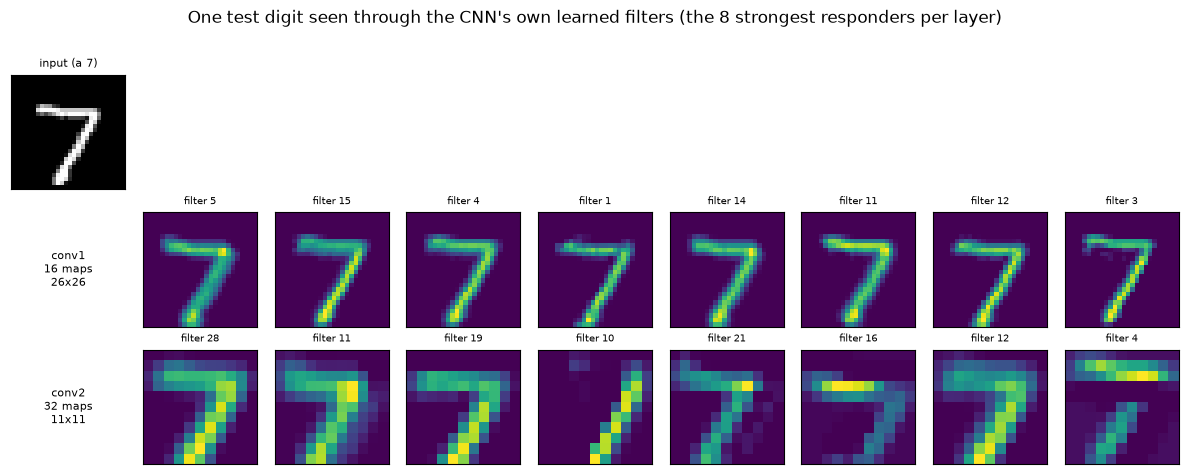


Of conv1's 16 filters, 0 produced no response at all on this image; strongest peak response 1.12, weakest 0.27.


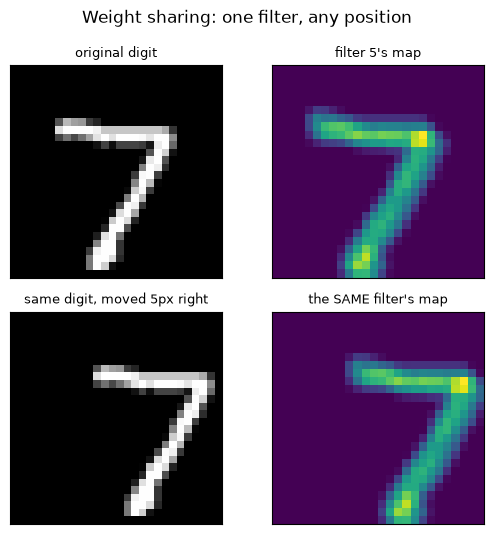

Filter 5's peak sits at column 18 in the original and column 23 after moving the digit 5 px right (moved by exactly 5).
Slide that map back 5 px and compare it with the original map: largest difference anywhere = 0.00e+00
The same 9 weights did the same job in a new place. A Dense layer would have had
to learn the shifted version separately, from separate examples.


In [5]:
# WHAT/WHY: pull the intermediate outputs out of the CNN we just trained and LOOK at
# them. A keras.Model can be built over the same layers to return their activations,
# so nothing is retrained — this is the network above, mid-thought, on one test digit.
digit_idx = 0
one_digit = x_test_n[digit_idx][None, ..., None]      # shape (1, 28, 28, 1)

feature_extractor = keras.Model(cnn.inputs, [cnn.layers[0].output, cnn.layers[2].output])
maps1, maps2 = [m[0] for m in feature_extractor.predict(one_digit, verbose=0)]
print(f"conv1 output: {maps1.shape[2]} feature maps of {maps1.shape[0]}x{maps1.shape[1]}, "
      f"produced by {cnn.layers[0].count_params()} parameters "
      f"({maps1.shape[2]} filters x 3x3 weights + {maps1.shape[2]} biases)")
print(f"conv2 output: {maps2.shape[2]} feature maps of {maps2.shape[0]}x{maps2.shape[1]}, "
      f"produced by {cnn.layers[2].count_params()} parameters")

# Show the 8 filters that responded most strongly to THIS image (ranking by peak response).
peak1, peak2 = maps1.max(axis=(0, 1)), maps2.max(axis=(0, 1))
top1, top2 = np.argsort(-peak1)[:8], np.argsort(-peak2)[:8]

fig, axes = plt.subplots(3, 9, figsize=(12, 4.6))
axes[0, 0].imshow(x_test[digit_idx], cmap="gray")
axes[0, 0].set_title(f"input (a {y_test[digit_idx]})", fontsize=8)
for ax in axes[0, 1:]:
    ax.axis("off")
for row, (maps, tops, label) in enumerate(
        [(maps1, top1, f"conv1\n{maps1.shape[2]} maps\n{maps1.shape[0]}x{maps1.shape[1]}"),
         (maps2, top2, f"conv2\n{maps2.shape[2]} maps\n{maps2.shape[0]}x{maps2.shape[1]}")], start=1):
    axes[row, 0].text(0.5, 0.5, label, ha="center", va="center", fontsize=8)
    axes[row, 0].axis("off")
    for j, f in enumerate(tops):
        axes[row, j + 1].imshow(maps[..., f], cmap="viridis")
        axes[row, j + 1].set_title(f"filter {f}", fontsize=7)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("One test digit seen through the CNN's own learned filters "
             "(the 8 strongest responders per layer)", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nOf conv1's {maps1.shape[2]} filters, {(peak1 == 0).sum()} produced no response at "
      f"all on this image; strongest peak response {peak1.max():.2f}, weakest {peak1.min():.2f}.")

# --- weight sharing, measured: shift the digit, and the feature map shifts with it ---
SHIFT = 5
shifted = np.roll(x_test_n[digit_idx], SHIFT, axis=1)      # move the digit 5 px right
maps1_shifted = feature_extractor.predict(shifted[None, ..., None], verbose=0)[0][0]
k = int(np.argmax(peak1))                                   # the strongest filter

fig, axes = plt.subplots(2, 2, figsize=(5.4, 5.4))
axes[0, 0].imshow(x_test[digit_idx], cmap="gray"); axes[0, 0].set_title("original digit", fontsize=9)
axes[0, 1].imshow(maps1[..., k], cmap="viridis"); axes[0, 1].set_title(f"filter {k}'s map", fontsize=9)
axes[1, 0].imshow(np.roll(x_test[digit_idx], SHIFT, axis=1), cmap="gray")
axes[1, 0].set_title(f"same digit, moved {SHIFT}px right", fontsize=9)
axes[1, 1].imshow(maps1_shifted[..., k], cmap="viridis")
axes[1, 1].set_title("the SAME filter's map", fontsize=9)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Weight sharing: one filter, any position")
plt.tight_layout()
plt.show()

r0, c0 = np.unravel_index(maps1[..., k].argmax(), maps1[..., k].shape)
r1, c1 = np.unravel_index(maps1_shifted[..., k].argmax(), maps1_shifted[..., k].shape)
back = np.roll(maps1_shifted[..., k], -SHIFT, axis=1)      # slide the map back
region = slice(0, maps1.shape[1] - SHIFT)                  # ignore the wrapped edge
print(f"Filter {k}'s peak sits at column {c0} in the original and column {c1} after moving "
      f"the digit {SHIFT} px right (moved by exactly {c1 - c0}).")
print(f"Slide that map back {SHIFT} px and compare it with the original map: "
      f"largest difference anywhere = {np.abs(back[:, region] - maps1[:, region, k]).max():.2e}")
print("The same 9 weights did the same job in a new place. A Dense layer would have had")
print("to learn the shifted version separately, from separate examples.")


### 👀 Read the two figures

**First figure — what the layers see.** The input is a 7. In the **conv1** row every one
of the eight maps still looks like that 7: a first convolution is close to the pixels, so
its filters mostly respond to ink and its edges, each brightening a different part of the
strokes. All 16 filters responded to this image — the printed line says **0** produced no
response at all, so nothing in this layer is dead. In the **conv2** row the resolution has
dropped to 11×11 (one pooling has already halved it) and the maps have become **selective**:
some light up almost entirely on the horizontal top bar, others almost entirely on the
diagonal down-stroke, with the rest of the digit dim. That is the hierarchy the lesson
claims — edges first, then combinations of edges — appearing after **two epochs** on 6,000
images.

Keep the parameter counts in view while you look: those 16 maps of 26×26 came out of
**160 numbers**. Sixteen images' worth of output from nine weights and a bias, sixteen
times over.

**Second figure — weight sharing, measured.** The same digit, moved 5 pixels to the right,
through the *same* filter. The bright response moves with it: peak column **18 → 23**,
exactly 5. Slide the new map back 5 pixels and compare it with the original, pixel by
pixel — the largest difference anywhere is **0.00e+00**. Not approximately the same
response in a new place: *identical*.

That is the whole argument for convolution in one measurement. Nine weights that work at
every position, versus a `Dense` layer which would have to meet the shifted 7 in its
training data and learn it again from scratch.

## Looking at predictions — including the failures

Accuracy is one number; the mistakes tell you *how* a model fails. Below: the top row shows correctly classified test digits, the bottom row shows misclassified ones (predicted label vs. true label in red).

CNN misclassified 75 of 1000 test images.


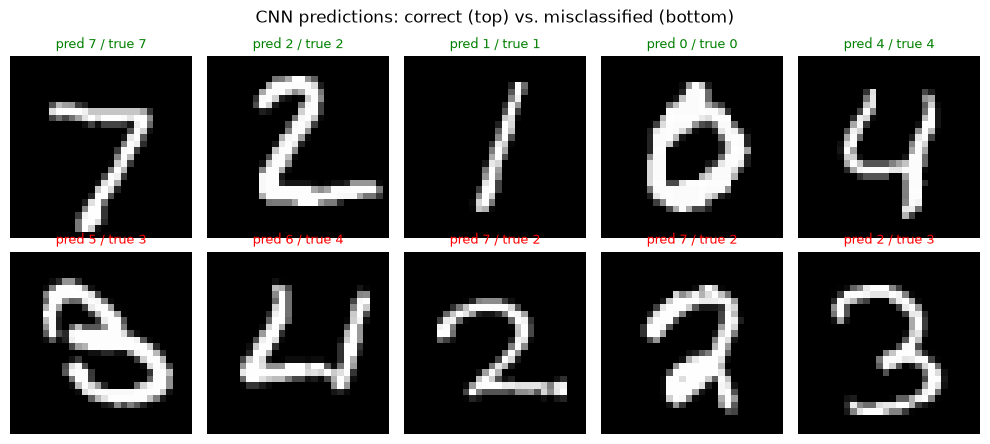

In [6]:
# Qualitative error analysis: put correct and wrong predictions side by side —
# the failures are often digits a human would hesitate on too.
pred_probs = cnn.predict(x_test_n[..., None], verbose=0)
preds = pred_probs.argmax(axis=1)
wrong_idx = np.where(preds != y_test)[0]
right_idx = np.where(preds == y_test)[0]
print(f"CNN misclassified {len(wrong_idx)} of {len(y_test)} test images.")

n_show = 5
fig, axes = plt.subplots(2, n_show, figsize=(10, 4.5))
for col in range(n_show):
    i = right_idx[col]
    axes[0, col].imshow(x_test[i], cmap="gray")
    axes[0, col].set_title(f"pred {preds[i]} / true {y_test[i]}", fontsize=9, color="green")
    axes[0, col].axis("off")

    j = wrong_idx[col % len(wrong_idx)]  # wraps if fewer than n_show failures
    axes[1, col].imshow(x_test[j], cmap="gray")
    axes[1, col].set_title(f"pred {preds[j]} / true {y_test[j]}", fontsize=9, color="red")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("correct")
fig.suptitle("CNN predictions: correct (top) vs. misclassified (bottom)")
plt.tight_layout()
plt.show()

## Transfer learning: standing on giants' shoulders

Our CNN needed 6,000 labeled digits. What if you only had a few hundred labels — a far more common situation in real projects? **Transfer learning** reuses a network that someone else already trained on a huge dataset, keeping its learned filters **frozen** and training only a tiny new classifier on top.

Here we load **MobileNetV2**, pre-trained on ImageNet (~1.3 million photos, 1,000 everyday object classes), *without* its final classification layer. We freeze all of its weights, feed it MNIST digits resized to 96x96 RGB, and let it convert each image into a 1,280-number feature vector. Then we train only a single softmax layer on **600 labeled digits** — the frozen base never changes.

Frozen MobileNetV2 parameters: 2,257,984 (trained by others, on ImageNet)
Feature vector per image:      1280 numbers
Labeled digits we use here:    600 train / 150 test


Trainable parameters we fit:   12,810
Transfer accuracy:             0.887 (on 150 test images, only 600 training labels)


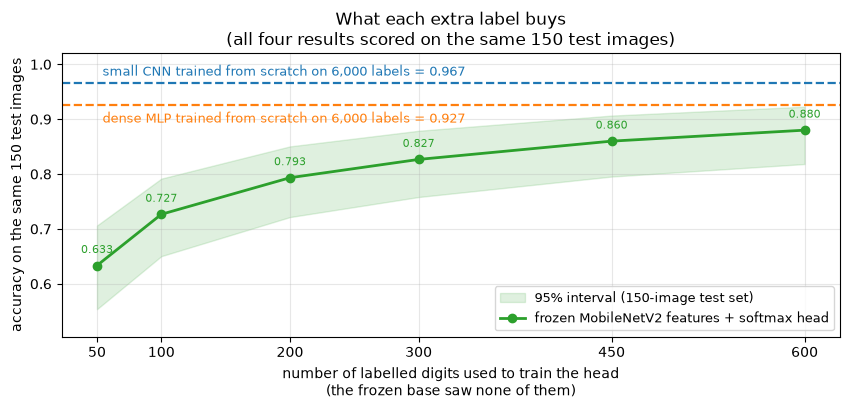

    50 labels -> 0.633
   100 labels -> 0.727
   200 labels -> 0.793
   300 labels -> 0.827
   450 labels -> 0.860
   600 labels -> 0.880

From-scratch on the same 150 images: dense MLP 0.927, small CNN 0.967 (both trained on 6,000 labels).
At 600 labels the head scores 0.880, 95% interval [0.818, 0.923].
The frozen-feature head never reaches the 6,000-label MLP at these budgets.


In [7]:
# Transfer learning: reuse a MobileNetV2 pre-trained on ImageNet as a frozen feature
# extractor and train ONLY a tiny softmax head — strong accuracy from just 600 labels.
import tensorflow as tf

# Load MobileNetV2 without its ImageNet classifier head (weights cached in ~/.keras)
base = keras.applications.MobileNetV2(
    input_shape=(96, 96, 3), include_top=False, weights="imagenet", pooling="avg"
)
base.trainable = False  # freeze: these weights will NOT be updated

def to_rgb96(images_uint8):
    """MNIST 28x28 grayscale -> 96x96 RGB, preprocessed for MobileNetV2."""
    x = tf.image.resize(images_uint8[..., None].astype("float32"), (96, 96))
    x = tf.image.grayscale_to_rgb(x)
    return keras.applications.mobilenet_v2.preprocess_input(x.numpy())

n_small_train, n_small_test = 600, 150
feat_train = base.predict(to_rgb96(x_train[:n_small_train]), batch_size=64, verbose=0)
feat_test = base.predict(to_rgb96(x_test[:n_small_test]), batch_size=64, verbose=0)

print(f"Frozen MobileNetV2 parameters: {base.count_params():,} (trained by others, on ImageNet)")
print(f"Feature vector per image:      {feat_train.shape[1]} numbers")
print(f"Labeled digits we use here:    {n_small_train} train / {n_small_test} test")

# The ONLY thing we train: one softmax layer on top of the frozen features
# The only trainable part: a single softmax layer on top of the frozen 1280-number features.
head = keras.Sequential(
    [keras.Input(shape=(feat_train.shape[1],)), keras.layers.Dense(10, activation="softmax")]
)
head.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
head.fit(feat_train, y_train[:n_small_train], epochs=10, batch_size=32, verbose=0)
_, transfer_acc = head.evaluate(feat_test, y_test[:n_small_test], verbose=0)

print(f"Trainable parameters we fit:   {head.count_params():,}")
print(f"Transfer accuracy:             {transfer_acc:.3f} "
      f"(on {n_small_test} test images, only {n_small_train} training labels)")

# WHAT/WHY: one accuracy number hides what transfer learning is actually about, which
# is LABELS, not accuracy. The expensive MobileNetV2 pass is already done, so re-training
# only the tiny softmax head on 50, 100, ... 600 of those frozen feature vectors costs
# almost nothing - and it turns the single number above into a curve. The two
# from-scratch models are re-scored (not retrained) on this SAME 150-image test set, so
# every line in the figure is measured on identical data.
label_budgets = [50, 100, 200, 300, 450, n_small_train]
budget_acc = []
for n_lab in label_budgets:
    keras.utils.set_random_seed(0)                      # identical start for every budget
    h = keras.Sequential([keras.Input(shape=(feat_train.shape[1],)),
                          keras.layers.Dense(10, activation="softmax")])
    h.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    h.fit(feat_train[:n_lab], y_train[:n_lab], epochs=10, batch_size=32, verbose=0)
    budget_acc.append(h.evaluate(feat_test, y_test[:n_small_test], verbose=0)[1])

# The two models from the first half, scored on the same 150 images (no retraining).
mlp_acc150 = mlp.evaluate(x_test_n[:n_small_test], y_test[:n_small_test], verbose=0)[1]
cnn_acc150 = cnn.evaluate(x_test_n[:n_small_test, ..., None], y_test[:n_small_test],
                          verbose=0)[1]

band = [wilson(a, n_small_test) for a in budget_acc]    # 150 images is a small test set

fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.fill_between(label_budgets, [b[0] for b in band], [b[1] for b in band],
                color="tab:green", alpha=0.15,
                label=f"95% interval ({n_small_test}-image test set)")
ax.plot(label_budgets, budget_acc, "o-", color="tab:green", lw=2,
        label="frozen MobileNetV2 features + softmax head")
ax.axhline(cnn_acc150, ls="--", color="tab:blue", lw=1.6)
ax.axhline(mlp_acc150, ls="--", color="tab:orange", lw=1.6)
ax.annotate(f"small CNN trained from scratch on 6,000 labels = {cnn_acc150:.3f}",
            (label_budgets[0], cnn_acc150), xytext=(4, 5), textcoords="offset points",
            fontsize=9, color="tab:blue")
ax.annotate(f"dense MLP trained from scratch on 6,000 labels = {mlp_acc150:.3f}",
            (label_budgets[0], mlp_acc150), xytext=(4, -13), textcoords="offset points",
            fontsize=9, color="tab:orange")
for x_lab, a in zip(label_budgets, budget_acc):
    ax.annotate(f"{a:.3f}", (x_lab, a), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=8, color="tab:green")
ax.set_xlabel("number of labelled digits used to train the head\n"
              "(the frozen base saw none of them)")
ax.set_ylabel(f"accuracy on the same {n_small_test} test images")
ax.set_title("What each extra label buys\n(all four results scored on the same 150 test images)")
ax.set_xticks(label_budgets)
ax.set_ylim(min(min(b[0] for b in band), mlp_acc150) - 0.05, 1.02)
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for n_lab, a in zip(label_budgets, budget_acc):
    print(f"  {n_lab:>4} labels -> {a:.3f}")
beat = [n for n, a in zip(label_budgets, budget_acc) if a >= mlp_acc150]
print(f"\nFrom-scratch on the same 150 images: dense MLP {mlp_acc150:.3f}, "
      f"small CNN {cnn_acc150:.3f} (both trained on 6,000 labels).")
print(f"At {label_budgets[-1]} labels the head scores {budget_acc[-1]:.3f}, "
      f"95% interval [{band[-1][0]:.3f}, {band[-1][1]:.3f}].")
print(f"The frozen-feature head matches or beats the 6,000-label MLP from "
      f"{beat[0]} labels onward." if beat else
      "The frozen-feature head never reaches the 6,000-label MLP at these budgets.")


### 👀 Read the curve

The green line is the **same frozen MobileNetV2** at every point — only the number of
labelled digits used to fit the 12,810-parameter head changes, left to right. The two
dashed lines are the models from the first half of this notebook, re-scored on these
identical 150 images (no retraining): each was trained on **6,000** labels. Putting all
four results on one test set is the only way this comparison means anything.

Three things to see, in order:

1. **The curve rises steeply, then flattens.** The first 150 extra labels (50 → 200) buy
   **+0.160** accuracy. The last 300 (300 → 600) buy **+0.053**. That shape is the
   practical argument for transfer learning: with borrowed features, a few hundred labels
   get you most of what you are going to get, and the point where more labelling stops
   paying arrives early.
2. **The green line never reaches either dashed line.** At its best — all 600 labels —
   the head scores **0.880**, against **0.927** for the dense MLP and **0.967** for the
   small CNN. Frozen ImageNet features are *out of domain* here: MobileNetV2 was trained
   on photographs of dogs, cars and cups, and a handwritten digit is nothing like them.
   Transfer learning is not free accuracy; it is accuracy borrowed from a *related*
   domain, and this figure is what borrowing from an unrelated one looks like.
3. **The green band is wide** — roughly ±5 points, because 150 test images is a small
   test set. At 600 labels the band's upper edge stops just short of the orange dash, so
   the gap to the MLP is at the very limit of what this test set can resolve; the gap to
   the blue dash (the CNN) is comfortably outside it. Read the *shape* of the curve and
   which lines it clears, never the third decimal of a single dot.

The honest summary: on **this** problem, borrowed features lose to a purpose-built model
trained on plenty of in-domain data. Their value is the left-hand end of the curve —
**0.727 from 100 labels**, with a base that cost someone else 1.3 million photographs to
train and cost us nothing.


### Why pre-trained models matter

Look at the leverage in the numbers above: we trained only **12,810** parameters on **600** labeled digits, yet reached **0.887** accuracy on this section's 150-image test set. The figure above puts that number in context by re-scoring the from-scratch models on those same 150 images: the dense MLP gets **0.927** and the CNN **0.967**, both from **6,000** labels — ten times more than the head used. The other **2.26 million** parameters were trained by someone else, on 1.3 million ImageNet photos, at a compute cost no classroom could afford — and we reused them for free, frozen, without a single gradient update. That is the core economics of transfer learning: the expensive part (learning general visual features like edges, textures, and shapes) is done once by a large lab and shared; the cheap part (adapting to *your* labels) is all you pay for.

This is why almost every production vision or language system today *starts* from a pre-trained model rather than from random weights: real projects rarely have millions of labeled examples, and pre-trained features make a few hundred labels usable. Note the honest caveat in our result: ImageNet contains photos of dogs, cars, and cups — nothing like handwritten digits — and the frozen features still transferred usefully — 0.727 from just 100 labels — but on matched test data they did not come close to our purpose-built CNN trained on 6,000 digits (0.880 vs 0.967). When the source and target domains are closer (e.g., classifying real-world photos), transfer typically wins outright, and *fine-tuning* — unfreezing some top layers and training them gently on your data — closes the gap further. That is the next tool you will reach for in later courses.

## 💬 Discuss

All three results are printed above: dense MLP **0.876** with **50,890**
parameters; CNN **0.925** with **30,762** parameters, 75 of 1,000 test images
wrong; frozen MobileNetV2 features + a 12,810-parameter head on **600 labels**
reaching **0.887** on its own 150-image test set.

1. The CNN beat the MLP by **+0.049** with **40% fewer parameters**. Both trained
   for 2 epochs on 6,000 images. **Is the fair conclusion "convolutions are
   better", or "convolutions are better at this budget"?** Say what you would run
   to distinguish those two claims, and predict which way it would come out.
2. Transfer learning got 0.887 from **600** labels; the CNN got 0.925 from
   **6,000** (on the matched 150-image test set of the figure above: 0.880 against
   0.967). You have a deadline, an unlabelled pile of images, and a budget that
   pays for either two weeks of engineering or 5,000 labels. **Which do you buy?**
   Change one thing about the scenario so your answer flips.
3. ImageNet contains dogs, cars and cups — nothing resembling handwriting — and
   the frozen features still transferred usefully. **Where would you expect
   transfer to fail outright?** Name a specific domain, and say what evidence
   would tell you *before* you spent the compute.
4. Esteva's model matched 21 dermatologists on a test set; Winkler's showed a
   related model keying on skin markings. **What would you require in the
   validation protocol** — beyond a held-out split — before letting a skin-lesion
   classifier near a clinic in your region?


## ⚠️ Where this breaks

- **Two epochs on 6,000 images is not a converged comparison.** Both models were
  still improving. The gap we measured is real *at this budget*; a fully trained
  MLP would close part of it, and a fully trained CNN would open it again. Always
  state the budget alongside the winner.
- **MNIST is the easiest image dataset in existence.** Every digit is centred,
  size-normalised, high-contrast and photographed against white. Nothing in a
  0.925 here transfers to photographs with clutter, lighting, rotation or scale
  variation — which is exactly why the *transfer* section reached only 0.887 on
  data that was never made for it.
- **CNNs assume locality and translation invariance.** Both hold for images and
  fail for tabular data, where column order is arbitrary. A convolution over
  spreadsheet columns is a meaningless operation performed confidently.
- **Frozen features cannot adapt.** Our MobileNetV2 base never received a single
  gradient. When the source domain (ImageNet photos) is far from the target
  (handwritten digits), frozen features lose to a small purpose-built model — and on a
  matched 150-image test set the loss is not close: **0.880 vs 0.967**. The fix is fine-tuning: unfreeze the top
  layers and train them gently, which costs compute and risks destroying the
  pre-trained features if the learning rate is too high.
- **A 150-image test set is a blunt instrument.** The headline 0.925 was measured
  on 1,000 images and 0.887 on 150. The label-efficiency figure removes the
  apples-to-oranges part by re-scoring all three models on the *same* 150 images —
  but 150 items still carry roughly ±5 points of uncertainty, which is why that
  figure is drawn with a confidence band and why the comparison in the previous
  bullet is suggestive rather than decisive.
- **Shortcut learning is the field's most common silent failure.** Winkler's ink
  markings, the husky-and-snow classifier, hospital-specific markers on chest
  X-rays — in every case, held-out accuracy was fine because the shortcut was in
  the test set too. **Cheaper check than any of the fancy alternatives:** test on
  data from a *different source* than you trained on, and look at what the model
  attends to (Unit 3, notebook 05).
- **When not to use a CNN:** small datasets of structured tabular features, where
  gradient-boosted trees remain a strong and much cheaper default; and any problem
  where the input has no spatial or temporal locality to exploit.


## 📚 References

1. LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). *Gradient-Based Learning Applied to Document Recognition*. Proceedings of the IEEE, 86(11), 2278–2324.
2. Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012). *ImageNet Classification with Deep Convolutional Neural Networks*. NeurIPS.
3. Sandler, M., Howard, A., Zhu, M., et al. (2018). *MobileNetV2: Inverted Residuals and Linear Bottlenecks*. CVPR. <https://arxiv.org/abs/1801.04381>
4. Dosovitskiy, A., Beyer, L., Kolesnikov, A., et al. (2021). *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale* (ViT). ICLR. <https://arxiv.org/abs/2010.11929>
5. Bai, S., Chen, K., Liu, X., et al. (2025). *Qwen2.5-VL Technical Report*. arXiv. <https://arxiv.org/abs/2502.13923>
6. Nassar, A., Marafioti, A., Omenetti, M., et al. (2025). *SmolDocling: An ultra-compact vision-language model for end-to-end multi-modal document conversion*. arXiv. <https://arxiv.org/abs/2503.11576>